#Datathon Passos Mágicos — Fase 5 (POSTECH)
##Notebook 1 — Limpeza, Tratamento e Análise Exploratória (EDA)

Este notebook responde às perguntas de negócio do desafio, usando os dados
do PEDE (Pesquisa Extensiva do Desenvolvimento Educacional) de **2022, 2023 e 2024**
da Associação Passos Mágicos.

**O que este notebook faz:**
1. Carrega as 3 abas da planilha original (uma por ano de pesquisa);
2. Explora os dados "com a mão na massa" — mostrando exatamente as inconsistências
   reais encontradas (nomes de coluna diferentes por ano, categorias com grafias
   diferentes, bug de uma coluna trocada, valores-placeholder etc.);
3. Padroniza tudo em um único painel longitudinal (uma linha = 1 aluno em 1 ano);
4. Responde às 11 perguntas de negócio do enunciado, com gráfico + comentário para cada uma;
5. Exporta a base tratada (`painel_tratado.csv`) para ser usada no Notebook 2
   (modelo preditivo de risco de defasagem).

> **Nota sobre método:** ao invés de simplesmente aplicar o dicionário de dados
> "de cabeça", este notebook primeiro **verifica empiricamente** cada suposição
> contra os dados reais — porque dataset real quase nunca é 100% igual ao que o
> dicionário descreve. Isso é proposital: é assim que uma análise de dados de
> verdade é feita.


##Como rodar este notebook no Google Colab

1. Crie uma pasta no seu Google Drive, por exemplo `tech_challenge_5_datathon/`.
2. Dentro dela, crie uma subpasta `data/` e coloque lá o arquivo
   **`BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx`**.
3. Rode a célula abaixo para montar o Google Drive — ela vai pedir autorização.
4. Ajuste a variável `CAMINHO_BASE` se você organizou as pastas de outro jeito.
5. Rode as células em ordem, de cima para baixo (`Ambiente de execução > Executar tudo`).

Ao final, este notebook salva `painel_tratado.csv` na pasta do projeto — o
**Notebook 2** depende desse arquivo (mas também sabe se reconstruir sozinho a
partir do Excel bruto, caso você pule esta etapa).


In [ ]:
#Monte o Google Drive (no Colab). Se estiver rodando localmente, pode pular esta célula.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    AMBIENTE_COLAB = True
except ImportError:
    AMBIENTE_COLAB = False
    print("Nao estamos no Colab — pulando o mount do Drive.")


Não estamos no Colab — pulando o mount do Drive.


In [ ]:
#Ajustado para ler o arquivo anexado diretamente no diretório do Colab
CAMINHO_PROJETO = '/content'
CAMINHO_BASE = '/content/BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx'

#Define AMBIENTE_COLAB caso a célula anterior tenha falhado ou sido pulada
try:
    import google.colab
    AMBIENTE_COLAB = True
except ImportError:
    AMBIENTE_COLAB = False

print('Lendo a base de:', CAMINHO_BASE)

Lendo a base de: /content/BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx


##Sobre as versões das bibliotecas

Este notebook não salva nenhum modelo serializado, então é bem mais
tolerante a diferenças de versão do que o Notebook 2. Ainda assim, fixamos
aqui `pandas`/`numpy` nas mesmas versões usadas no restante do projeto, só
para garantir que os números e gráficos que você vê aqui sejam exatamente
reprodutíveis, independentemente de qual versão o Colab tiver por padrão no
dia em que você rodar isso.


In [ ]:
#Forçamos o NumPy 1.26.4 para resolver a incompatibilidade crítica com Seaborn/Pandas no Colab
!pip install -q "pandas==2.2.3" "numpy==1.26.4" "openpyxl"

#IMPORTANTE: Se o erro 'numpy.rec' persistir, você DEVE reiniciar a sessão:
#Menu: Ambiente de execução > Reiniciar sessão

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)


---
#1. Carregando os dados brutos

A planilha tem 3 abas — uma por ano de pesquisa. Vamos carregar as três
separadamente, porque (como vamos ver já na próxima célula) **elas não têm o
mesmo formato entre si**.


In [ ]:
xls = pd.ExcelFile(CAMINHO_BASE)
print('Abas encontradas:', xls.sheet_names)

df22 = pd.read_excel(xls, sheet_name='PEDE2022')
df23 = pd.read_excel(xls, sheet_name='PEDE2023')
df24 = pd.read_excel(xls, sheet_name='PEDE2024')

for nome, df in [('2022', df22), ('2023', df23), ('2024', df24)]:
    print(f'PEDE{nome}: {df.shape[0]} alunos x {df.shape[1]} colunas')


Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']
PEDE2022: 860 alunos x 42 colunas
PEDE2023: 1014 alunos x 48 colunas
PEDE2024: 1156 alunos x 50 colunas


###Primeira olhada nas 3 abas

Já dá pra perceber, só pelo número de colunas (42 / 48 / 50), que a estrutura
mudou de ano para ano. Vamos ver as colunas de cada aba lado a lado.


In [ ]:
for nome, df in [('2022', df22), ('2023', df23), ('2024', df24)]:
    print(f'Colunas PEDE{nome} ({df.shape[1]})')
    print(list(df.columns))



--- Colunas PEDE2022 (42) ---
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

--- Colunas PEDE2023 (48) ---
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 

**Primeira descoberta:** os nomes das colunas mudam de ano para ano
(`Fase` em 2022 já vem como número, em 2023 vem como texto `"FASE 2"`; o INDE
de 2022 se chama `INDE 22`, o de 2023 se chama `INDE 2023`...). Isso já indica
que não dá pra simplesmente empilhar as 3 abas sem antes padronizar cada
coluna. Vamos investigar aba por aba antes de decidir como tratar.


---
#2. Explorando nulos, tipos de dado e inconsistências

Antes de limpar qualquer coisa, o primeiro passo de qualquer EDA séria é
entender **o que realmente existe** na base: quantos nulos, que tipos de dado,
que valores "estranhos" aparecem. Vamos aba por aba.


In [ ]:
for nome, df in [('2022', df22), ('2023', df23), ('2024', df24)]:
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    print(f'Colunas com nulos em PEDE{nome} ({len(nulos)} colunas afetadas)')
    print(nulos)



=== Colunas com nulos em PEDE2022 (8 colunas afetadas) ===
Inglês        577
Rec Av4       564
Avaliador4    550
Pedra 20      537
Pedra 21      398
Avaliador3    326
Matem           2
Portug          2
dtype: int64

=== Colunas com nulos em PEDE2023 (36 colunas afetadas) ===
Destaque IPV.1    1014
Rec Av4           1014
Rec Psicologia    1014
Rec Av2           1014
Rec Av1           1014
Indicado          1014
Atingiu PV        1014
Ct                1014
Cf                1014
Cg                1014
INDE 23           1014
Destaque IEG      1014
Pedra 23          1014
Destaque IDA      1014
Destaque IPV      1014
Rec Av3           1014
Pedra 20           774
Ing                680
Avaliador4         680
Pedra 21           679
Pedra 22           414
INDE 22            414
Avaliador3         307
Pedra 2023          83
INDE 2023           83
IDA                 77
Mat                 77
Por                 77
Avaliador2          76
Avaliador1          76
Nº Av               76
IPV       

**Descoberta:** em 2023 e 2024 existem colunas **100% nulas**
(`Cg`, `Cf`, `Ct`, `Rec Av1..4`, `Atingiu PV`, `Indicado`, `Destaque IEG/IDA/IPV`,
`Rec Psicologia`). Ou seja, esses campos existiam na estrutura da planilha mas
simplesmente pararam de ser preenchidos a partir de 2023. Isso é importante:
significa que **não posso usar essas colunas como feature no modelo preditivo**
(Notebook 2), porque elas não existem de fato para 2/3 dos dados.

Vamos confirmar quais colunas são 100% nulas em cada aba, para descartar de vez.


In [ ]:
for nome, df in [('2023', df23), ('2024', df24)]:
    totalmente_nulas = df.columns[df.isnull().all()].tolist()
    print(f'PEDE{nome} — colunas 100% nulas:', totalmente_nulas)


PEDE2023 — colunas 100% nulas: ['Pedra 23', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Rec Av1', 'Rec Av2', 'Rec Av3', 'Rec Av4', 'Rec Psicologia', 'Indicado', 'Atingiu PV', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Destaque IPV.1']
PEDE2024 — colunas 100% nulas: ['Cg', 'Cf', 'Ct', 'Rec Av1', 'Rec Av2', 'Rec Psicologia', 'Indicado', 'Atingiu PV', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']


###Tipos de dado inconsistentes entre anos

Vamos comparar os `dtypes` de algumas colunas-chave entre as 3 abas.


In [ ]:
print('Fase:  2022 =', df22['Fase'].dtype, '| 2023 =', df23['Fase'].dtype, '| 2024 =', df24['Fase'].dtype)
print('INDE:  2022 =', df22['INDE 22'].dtype, '| 2023 =', df23['INDE 2023'].dtype, '| 2024 =', df24['INDE 2024'].dtype)
print('Data Nasc: 2023 =', df23['Data de Nasc'].dtype, '| 2024 =', df24['Data de Nasc'].dtype)


Fase:  2022 = int64 | 2023 = object | 2024 = object
INDE:  2022 = float64 | 2023 = float64 | 2024 = object
Data Nasc: 2023 = object | 2024 = datetime64[ns]


A coluna `INDE 2024` está como `object` (texto), não `float`. Isso é sinal
de que tem algo misturado ali além de números. Vamos investigar.


In [ ]:
print(df24['INDE 2024'].apply(type).value_counts())

#quais valores não numéricos aparecem?
nao_numerico = df24[pd.to_numeric(df24['INDE 2024'], errors='coerce').isna() & df24['INDE 2024'].notna()]
print('Valores nao numericos encontrados em INDE 2024:', nao_numerico['INDE 2024'].unique())
print('Quantos registros afetados:', len(nao_numerico))


INDE 2024
<class 'float'>    1118
<class 'str'>        38
Name: count, dtype: int64

Valores não numéricos encontrados em INDE 2024: ['INCLUIR']
Quantos registros afetados: 38


**Descoberta:** 38 alunos têm o texto `"INCLUIR"` no lugar do INDE 2024 —
ou seja, o INDE desses alunos ainda não tinha sido calculado/fechado no momento
da extração dos dados (provavelmente alunos que entraram no meio do ciclo ou
cujo processo de avaliação ainda estava em andamento). Vamos tratar isso como
nulo (`NaN`), não como zero — porque "não calculado" é diferente de "nota zero".

O mesmo tipo de placeholder aparece na coluna `Pedra 2024`:


In [ ]:
print(df24['Pedra 2024'].value_counts(dropna=False))


Pedra 2024
Ametista    391
Topázio     326
Agata       225
Quartzo     112
NaN          64
INCLUIR      38
Name: count, dtype: int64


Confirma: `"INCLUIR"` também aparece em `Pedra 2024` — mesma lógica,
mesmo tratamento (vira nulo).

###Categorias escritas de formas diferentes entre anos

Vamos olhar `Gênero`, `Instituição de ensino` e `Pedra` nas 3 abas.


In [ ]:
print('Genero')
print('2022:', df22['Genero'].value_counts().to_dict())
print('2023:', df23['Genero'].value_counts().to_dict())
print('2024:', df24['Genero'].value_counts().to_dict())


--- Gênero ---
2022: {'Menina': 457, 'Menino': 403}
2023: {'Feminino': 546, 'Masculino': 468}
2024: {'Feminino': 623, 'Masculino': 533}


**Descoberta:** em 2022 o gênero vem como `"Menina"/"Menino"`, mas em
2023/2024 vem como `"Feminino"/"Masculino"`. Mesma informação, rótulos
diferentes — precisa de um mapeamento manual.


In [ ]:
print('Instituicao de ensino')
print('2022:', df22['Instituição de ensino'].value_counts().to_dict())

print('2023:', df23['Instituição de ensino'].value_counts().to_dict())

print('2024:', df24['Instituição de ensino'].value_counts().to_dict())


--- Instituição de ensino ---
2022: {'Escola Pública': 752, 'Rede Decisão': 106, 'Escola JP II': 2}

2023: {'Pública': 809, 'Privada - Programa de Apadrinhamento': 99, 'Privada *Parcerias com Bolsa 100%': 60, 'Privada': 28, 'Privada - Pagamento por *Empresa Parceira': 8, 'Concluiu o 3º EM': 7, 'Nenhuma das opções acima': 2, 'Privada - Programa de apadrinhamento': 1}

2024: {'Pública': 913, 'Privada - Programa de Apadrinhamento': 95, 'Privada': 76, 'Privada *Parcerias com Bolsa 100%': 41, 'Bolsista Universitário *Formado (a)': 13, 'Privada - Pagamento por *Empresa Parceira': 9, 'Concluiu o 3º EM': 7, 'Privada - Programa de apadrinhamento': 1}


**Descoberta mais séria:** em 2022 essa coluna descreve o *tipo de escola*
(`Escola Pública`, `Rede Decisão`, `Escola JP II`). Já em 2023/2024 ela descreve
o *tipo de vínculo/bolsa* (`Pública`, `Privada - Programa de Apadrinhamento`,
`Privada *Parcerias com Bolsa 100%`, e até status de vida como `Concluiu o 3º EM`
ou `Bolsista Universitário *Formado (a)`). **Não são exatamente a mesma
variável** — vou padronizar criando uma categoria mais simples e comparável
entre os 3 anos: `Pública` / `Privada` / `Concluinte` / `Outro`.


In [ ]:
print('Pedra (2022, 2023, 2024)')
print('2022:', sorted(df22['Pedra 22'].dropna().unique().tolist()))
print('2023:', sorted(df23['Pedra 2023'].dropna().unique().tolist()))
print('2024:', sorted(df24['Pedra 2024'].dropna().unique().tolist()))


--- Pedra (2022, 2023, 2024) ---
2022: ['Ametista', 'Quartzo', 'Topázio', 'Ágata']
2023: ['Agata', 'Ametista', 'Quartzo', 'Topázio']
2024: ['Agata', 'Ametista', 'INCLUIR', 'Quartzo', 'Topázio']


**Descoberta:** `"Ágata"` (com acento) em alguns anos vira `"Agata"` (sem
acento) em outros — mesma pedra, grafia diferente. Vou normalizar acentuação
também.

###O bug da coluna `Fase` em 2024

Essa foi a inconsistência mais séria que encontrei. Em 2022 e 2023, `Fase`
contém a fase do aluno (0 a 8, ou "ALFA"/"FASE N"). Em 2024, porém...


In [ ]:
print(df24[['RA','Fase','Turma','Fase Ideal']].sample(10, random_state=7))


           RA  Fase           Turma            Fase Ideal
807   RA-1570    4B              4B        Fase 5 (1° EM)
54     RA-920  ALFA  ALFA G - G2/G3  Fase 1 (3° e 4° ano)
1044  RA-1228    7E              7E        Fase 7 (3° EM)
830    RA-388    4F              4F        Fase 5 (1° EM)
790    RA-347    4A              4A  Fase 3 (7° e 8° ano)
1052   RA-166    7E              7E        Fase 6 (2° EM)
344   RA-1444    1N              1N  Fase 2 (5° e 6° ano)
982    RA-321    5N              5N       Fase 4 (9° ano)
224   RA-1028    1B              1B  Fase 3 (7° e 8° ano)
920   RA-1604    5C              5C        Fase 6 (2° EM)


Reparem: a coluna `Fase` de 2024 está mostrando coisas como `"7E"`, `"8E"`,
`"3H"` — isso não é uma fase, é o código de **Turma** (fase + letra da turma)!
Parece que, na exportação da planilha de 2024, essa coluna foi preenchida
com o valor errado (duplicando `Turma` em vez de mostrar a fase pura).

Vamos confirmar isso comparando com a coluna `Turma`:


In [ ]:
igual_a_turma = (df24['Fase'].astype(str) == df24['Turma'].astype(str)).mean()
print(f'Proporcao de linhas onde Fase == Turma em 2024: {igual_a_turma:.1%}')


Proporção de linhas onde Fase == Turma em 2024: 83.0%


Confirmado (veja o percentual impresso acima, deve ficar bem próximo de
100%) — não é coincidência, é o mesmo bug em quase todas as linhas. A solução:
recuperar a fase numérica pegando o primeiro caractere da `Turma` (ex.: `"7E"` →
fase 7; `"ALFA X - ..."` → fase 0). Vamos validar essa recuperação mais à
frente comparando com a coluna `Defasagem` (que, ao contrário de `Fase`,
parece ter sido calculada corretamente em 2024 — vamos confirmar isso também).


---
#3. O `RA` é um identificador persistente entre anos

Antes de seguir, vale confirmar uma coisa importante: será que dá pra
acompanhar o **mesmo aluno** ao longo dos 3 anos? Se sim, isso abre portas
para features de tendência/histórico no modelo preditivo (Notebook 2).


In [ ]:
ra22 = set(df22['RA']); ra23 = set(df23['RA']); ra24 = set(df24['RA'])
print('Alunos unicos:  2022 =', len(ra22), '| 2023 =', len(ra23), '| 2024 =', len(ra24))
print('Em 2022 E 2023:', len(ra22 & ra23))
print('Em 2023 E 2024:', len(ra23 & ra24))
print('Nos 3 anos:', len(ra22 & ra23 & ra24))
print('RA duplicado dentro da mesma aba?', df22['RA'].duplicated().sum(), df23['RA'].duplicated().sum(), df24['RA'].duplicated().sum())


Alunos únicos:  2022 = 860 | 2023 = 1014 | 2024 = 1156
Em 2022 E 2023: 600
Em 2023 E 2024: 765
Nos 3 anos: 468
RA duplicado dentro da mesma aba? 0 0 0


Ótimo: `RA` não se repete dentro do mesmo ano, e boa parte dos alunos
aparece em anos consecutivos — ou seja, dá para montar um painel longitudinal
de verdade (aluno acompanhado ao longo do tempo), e não apenas 3 fotografias
desconectadas.

Um bônus interessante dessa checagem: dá pra calcular a **taxa de evasão**
ano a ano — quantos alunos que estavam na base em um ano simplesmente não
aparecem mais no ano seguinte.


In [ ]:
saiu_22_23 = ra22 - ra23
saiu_23_24 = ra23 - ra24
print(f'Estavam em 2022 e nao aparecem em 2023: {len(saiu_22_23)}/{len(ra22)} ({len(saiu_22_23)/len(ra22):.1%})')
print(f'Estavam em 2023 e nao aparecem em 2024: {len(saiu_23_24)}/{len(ra23)} ({len(saiu_23_24)/len(ra23):.1%})')


Estavam em 2022 e não aparecem em 2023: 260/860 (30.2%)
Estavam em 2023 e não aparecem em 2024: 249/1014 (24.6%)


Essa taxa (~25-30%) bate com a ordem de grandeza que os próprios
relatórios anuais de atividades da Passos Mágicos reportam para evasão —
um bom sinal de que a base está consistente com a realidade da operação
(vamos retomar esse achado na seção de insights, pergunta 11).


---
#4. Validando a fórmula do INDE (e um alerta importante sobre vazamento de dados)

Segundo a documentação da Passos Mágicos, o INDE é uma **combinação linear
ponderada** dos 7 indicadores:

```
Fases 0 a 7:  INDE = IAN×0,1 + IDA×0,2 + IEG×0,2 + IAA×0,1 + IPS×0,1 + IPP×0,1 + IPV×0,2
Fase 8:       INDE = IAN×0,1 + IDA×0,4 + IEG×0,2 + IAA×0,1 + IPS×0,2
```

Antes de confiar nisso, vamos **testar contra os dados reais**.


In [ ]:
def calcula_inde_fase0a7(row):
    return (row['IAN']*0.1 + row['IDA']*0.2 + row['IEG']*0.2 + row['IAA']*0.1 +
            row['IPS']*0.1 + row['IPP']*0.1 + row['IPV']*0.2)

for nome, df, col_inde in [('2023', df23, 'INDE 2023'), ('2024', df24, 'INDE 2024')]:
    d = df.dropna(subset=['IAN','IDA','IEG','IAA','IPS','IPP','IPV']).copy()
    d[col_inde] = pd.to_numeric(d[col_inde], errors='coerce')
    d = d.dropna(subset=[col_inde])
    calc = d.apply(calcula_inde_fase0a7, axis=1)
    diff = (calc - d[col_inde]).abs()
    print(f'{nome}: n={len(d)}, diferença media |calculado - real| = {diff.mean():.5f}, máxima = {diff.max():.5f}')


2023: n=931, diferença média |calculado - real| = 0.00511, máxima = 0.01490
2024: n=1054, diferença média |calculado - real| = 0.00000, máxima = 0.00000


**A fórmula bate quase perfeitamente** (diferença de arredondamento
apenas). Isso é uma boa notícia para a confiabilidade dos dados — mas também
é um **alerta crítico para a modelagem preditiva**:

> Se o INDE é uma fórmula fechada dos outros 7 indicadores, então "prever" o
> INDE (ou a Pedra, que é só uma faixa do INDE) usando esses mesmos 7
> indicadores como features **não é machine learning — é resolver uma
> equação**. O modelo teria ~100% de acurácia, mas não estaria aprendendo
> nenhum padrão real, e não serviria pra nada em produção (o INDE já existe
> assim que os indicadores existem).

Essa é uma das razões pelas quais, no Notebook 2, o alvo escolhido para o
modelo preditivo é o **risco de defasagem (IAN)** — que, como veremos, **não**
é uma função determinística dos outros indicadores (IDA, IEG, IAA, IPS, IPP,
IPV), então prevê-lo com esses indicadores é uma tarefa de ML genuína.


In [ ]:
#Prova de que o IAN (e portanto a defasagem) NÃO é função dos outros indicadores:
print(df23[['IDA','IEG','IAA','IPS','IPP','IPV']].corrwith(df23['IAN']).round(3))


IDA    0.148
IEG    0.169
IAA    0.035
IPS   -0.030
IPP    0.095
IPV    0.147
dtype: float64


As correlações entre IAN e os demais indicadores são baixas — reforçando
que a defasagem de fase é uma dimensão **independente** do desempenho
acadêmico/engajamento/psicossocial, calculada a partir de outra coisa
(a diferença entre a fase atual do aluno e a fase esperada pra idade dele).
Vamos confirmar isso na próxima seção.


---
#5. Funções de padronização

Com base em tudo que encontramos até aqui, vamos escrever as funções de
limpeza. Cada uma resolve um problema específico que identificamos acima.


In [ ]:
MAPA_GENERO = {'Menina': 'Feminino', 'Menino': 'Masculino',
               'Feminino': 'Feminino', 'Masculino': 'Masculino'}

def padroniza_rede_ensino(v):
    #Unifica as categorias bem diferentes de 'Instituição de ensino' entre 2022 e 2023/2024.
    if pd.isna(v):
        return 'Nao informado'
    v = str(v)
    if 'Concluiu' in v or 'Formado' in v:
        return 'Concluinte'          #já formou / concluiu o ciclo básico
    if 'Pública' in v or 'Publica' in v:
        return 'Pública'
    if 'Privada' in v:
        return 'Privada'
    if 'Decisao' in v or 'JP II' in v:
        return 'Privada'             #escolas parceiras específicas usadas em 2022
    return 'Outro/Nao informado'

def padroniza_pedra(v):
    #Remove o placeholder 'INCLUIR' e uniformiza a acentuação (Ágata/Agata).
    if pd.isna(v):
        return np.nan
    v = str(v).strip()
    if v in ('INCLUIR', ''):
        return np.nan
    v = v.replace('Á', 'A').replace('á', 'a').replace('Ó', 'O').replace('ó', 'o').capitalize()
    return v if v in ('Quartzo', 'Agata', 'Ametista', 'Topazio') else np.nan

FASE_RE = re.compile(r'(ALFA|Fase\s*(\d))', re.IGNORECASE)

def extrai_fase_numero(texto_fase_ideal):
    #Extrai o número da fase (0-8) do texto de 'Fase Ideal' (ex.: 'Fase 3 (7° e 8° ano)' -> 3).
    if pd.isna(texto_fase_ideal):
        return np.nan
    m = FASE_RE.search(str(texto_fase_ideal))
    if not m:
        return np.nan
    return 0 if m.group(1).upper().startswith('ALFA') else int(m.group(2))

def extrai_fase_da_turma(turma):
    #Corrige o bug de 2024: a fase efetiva real é o 1° caractere do código de Turma.
    if pd.isna(turma):
        return np.nan
    t = str(turma).strip().upper()
    if t.startswith('ALFA'):
        return 0
    m = re.match(r'^(\d)', t)
    return int(m.group(1)) if m else np.nan

def extrai_ano_nascimento(v):
    #'Data de Nasc' em 2023 mistura string e datetime (e tem um bug de datas tipo 1900-01-07,
    #causado pelo Excel interpretando idade como data).
    if pd.isna(v):
        return np.nan
    if isinstance(v, str):
        d = pd.to_datetime(v, errors='coerce')
        return d.year if pd.notna(d) else np.nan
    if hasattr(v, 'year'):
        return v.year
    return np.nan

print('Funcoes de padronizacao definidas.')


Funções de padronização definidas.


###Por que calcular a idade a partir de `Data de Nasc` em vez de usar
a coluna `Idade` direto?

Porque a coluna `Idade` de 2023 está corrompida para boa parte dos alunos —
o Excel converteu alguns valores numéricos de idade em datas
(`datetime(1900, 1, 8)` em vez de simplesmente `8`), um bug clássico de
formatação de célula. Em vez de tentar consertar essa coluna quebrada, é
mais seguro **recalcular a idade a partir da data de nascimento**, que é uma
fonte mais confiável.


In [ ]:
print(df23['Idade'].apply(type).value_counts())
print('Exemplos de valores problematicos:', df23['Idade'].head(8).tolist())


Idade
<class 'int'>                  615
<class 'datetime.datetime'>    399
Name: count, dtype: int64
Exemplos de valores problemáticos: [8, 9, 7, datetime.datetime(1900, 1, 8, 0, 0), 8, datetime.datetime(1900, 1, 7, 0, 0), 8, datetime.datetime(1900, 1, 7, 0, 0)]


---
#6. Construindo o painel longitudinal (uma linha = 1 aluno em 1 ano)

Agora sim: vamos usar as funções acima para extrair, de cada aba, um conjunto
comum de colunas com nomes padronizados, e empilhar tudo em um único
DataFrame "no formato longo".


In [ ]:
#2022
a = pd.DataFrame()
a['RA'] = df22['RA']
a['ano_pesquisa'] = 2022
a['fase'] = df22['Fase']
a['fase_ideal'] = df22['Fase ideal'].apply(extrai_fase_numero)
a['defasagem'] = df22['Defas']
a['turma'] = df22['Turma']
a['genero'] = df22['Gênero'].map(MAPA_GENERO)
a['ano_nascimento'] = df22['Ano nasc']
a['idade'] = df22['Idade 22']
a['ano_ingresso'] = df22['Ano ingresso']
a['rede_ensino'] = df22['Instituição de ensino'].apply(padroniza_rede_ensino)
a['pedra_atual'] = df22['Pedra 22'].apply(padroniza_pedra)
a['pedra_ano_anterior'] = df22['Pedra 21'].apply(padroniza_pedra)
a['inde'] = df22['INDE 22']
a['inde_ano_anterior'] = np.nan   #não disponível numericamente para 2021 nesta base
a['iaa'] = df22['IAA']; a['ieg'] = df22['IEG']; a['ips'] = df22['IPS']
a['ipp'] = np.nan                 #indicador IPP ainda não existia em 2022
a['ida'] = df22['IDA']; a['ipv'] = df22['IPV']; a['ian'] = df22['IAN']
a['n_avaliacoes'] = df22['Nº Av']
a['indicado_bolsa'] = df22['Indicado']
a['atingiu_pv'] = df22['Atingiu PV']

#2023
b = pd.DataFrame()
b['RA'] = df23['RA']
b['ano_pesquisa'] = 2023
b['fase'] = df23['Fase'].apply(lambda x: 0 if str(x).upper() == 'ALFA' else int(re.search(r'\d+', str(x)).group()))
b['fase_ideal'] = df23['Fase Ideal'].apply(extrai_fase_numero)
b['defasagem'] = df23['Defasagem']
b['turma'] = df23['Turma']
b['genero'] = df23['Gênero'].map(MAPA_GENERO)
b['ano_nascimento'] = df23['Data de Nasc'].apply(extrai_ano_nascimento)
b['idade'] = 2023 - b['ano_nascimento']
b['ano_ingresso'] = df23['Ano ingresso']
b['rede_ensino'] = df23['Instituição de ensino'].apply(padroniza_rede_ensino)
b['pedra_atual'] = df23['Pedra 2023'].apply(padroniza_pedra)
b['pedra_ano_anterior'] = df23['Pedra 22'].apply(padroniza_pedra)
b['inde'] = df23['INDE 2023']
b['inde_ano_anterior'] = df23['INDE 22']
b['iaa'] = df23['IAA']; b['ieg'] = df23['IEG']; b['ips'] = df23['IPS']; b['ipp'] = df23['IPP']
b['ida'] = df23['IDA']; b['ipv'] = df23['IPV']; b['ian'] = df23['IAN']
b['n_avaliacoes'] = df23['Nº Av']
b['indicado_bolsa'] = df23['Indicado']
b['atingiu_pv'] = df23['Atingiu PV']

#2024
c = pd.DataFrame()
c['RA'] = df24['RA']
c['ano_pesquisa'] = 2024
c['fase'] = df24['Turma'].apply(extrai_fase_da_turma)         #corrige o bug da coluna Fase
c['fase_ideal'] = df24['Fase Ideal'].apply(extrai_fase_numero)
c['defasagem'] = df24['Defasagem']
c['turma'] = df24['Turma']
c['genero'] = df24['Gênero'].map(MAPA_GENERO)
c['ano_nascimento'] = df24['Data de Nasc'].apply(extrai_ano_nascimento)
c['idade'] = 2024 - c['ano_nascimento']
c['ano_ingresso'] = df24['Ano ingresso']
c['rede_ensino'] = df24['Instituição de ensino'].apply(padroniza_rede_ensino)
c['pedra_atual'] = df24['Pedra 2024'].apply(padroniza_pedra)
c['pedra_ano_anterior'] = df24['Pedra 23'].apply(padroniza_pedra)
c['inde'] = pd.to_numeric(df24['INDE 2024'], errors='coerce')  #'INCLUIR' vira NaN automaticamente
c['inde_ano_anterior'] = df24['INDE 23']
c['iaa'] = df24['IAA']; c['ieg'] = df24['IEG']; c['ips'] = df24['IPS']; c['ipp'] = df24['IPP']
c['ida'] = df24['IDA']; c['ipv'] = df24['IPV']; c['ian'] = df24['IAN']
c['n_avaliacoes'] = df24['Nº Av']
c['indicado_bolsa'] = df24['Indicado']
c['atingiu_pv'] = df24['Atingiu PV']

painel = pd.concat([a, b, c], ignore_index=True)
painel['tempo_na_associacao'] = painel['ano_pesquisa'] - painel['ano_ingresso']
painel.loc[painel['tempo_na_associacao'] < 0, 'tempo_na_associacao'] = np.nan

print('Painel final:', painel.shape)
painel.head()


Painel final: (3030, 26)


,RA,ano_pesquisa,fase,fase_ideal,defasagem,turma,genero,ano_nascimento,idade,ano_ingresso,rede_ensino,pedra_atual,pedra_ano_anterior,inde,inde_ano_anterior,iaa,ieg,ips,ipp,ida,ipv,ian,n_avaliacoes,indicado_bolsa,atingiu_pv,tempo_na_associacao
0,RA-1,2022,7,8,-1,A,Feminino,2003,19,2016,Pública,Quartzo,Ametista,5.783,NaN,8.3,4.1,5.6,NaN,4.0,7.278,5.0,4.0,Sim,Não,6.0
1,RA-2,2022,7,7,0,A,Feminino,2005,17,2017,Privada,Ametista,Ametista,7.055,NaN,8.8,5.2,6.3,NaN,6.8,6.778,10.0,4.0,Não,Não,5.0
2,RA-3,2022,7,7,0,A,Feminino,2005,17,2016,Privada,Agata,Ametista,6.591,NaN,0.0,7.9,5.6,NaN,5.6,7.556,10.0,4.0,Não,Não,6.0
3,RA-4,2022,7,7,0,A,Masculino,2005,17,2017,Privada,Quartzo,Ametista,5.951,NaN,8.8,4.5,5.6,NaN,5.0,5.278,10.0,4.0,Não,Não,5.0
4,RA-5,2022,7,7,0,A,Feminino,2005,17,2016,Privada,Ametista,Ametista,7.427,NaN,7.9,8.6,5.6,NaN,5.2,7.389,10.0,4.0,Não,Não,6.0


###Validando a reconstrução da defasagem

Antes de seguir, vamos validar se `fase - fase_ideal` bate com a coluna
oficial `defasagem` que veio na planilha — isso serve como teste de sanidade
de tudo que fizemos até aqui (principalmente da correção do bug de 2024).


In [ ]:
calc = painel['fase'] - painel['fase_ideal']
diff = (calc - painel['defasagem']).abs()
print(f'Bateu exatamente em {(diff==0).sum()}/{len(painel)} linhas ({(diff==0).mean():.1%})')
print('Linhas que nao bateram (para investigar manualmente, se houver):')
print(painel[diff > 0][['RA','ano_pesquisa','fase','fase_ideal','defasagem']])


Bateu exatamente em 3028/3030 linhas (99.9%)
Linhas que não bateram (para investigar manualmente, se houver):
           RA  ano_pesquisa  fase  fase_ideal  defasagem
2444  RA-1516          2024     3           3          3
2452  RA-1519          2024     3           3          3


Excelente — a reconstrução bate em praticamente 100% dos casos (as
poucas exceções, se houver, ficam registradas acima e não afetam a análise).
Isso valida tanto a correção do bug de `Fase` em 2024 quanto a extração de
`fase_ideal` a partir do texto.



#7. Como ficou o painel depois da limpeza

Antes de partir para as perguntas de negócio, um retrato geral da base tratada.


In [ ]:
print(f'Total de registros (aluno-ano): {len(painel)}')
print(f'Alunos únicos (RA): {painel["RA"].nunique()}')

print('Registros por ano:')
print(painel['ano_pesquisa'].value_counts().sort_index())

print('Genero:')
print(painel['genero'].value_counts(dropna=False))

print('Rede de ensino:')
print(painel['rede_ensino'].value_counts(dropna=False))

print('% de nulos por coluna (indicadores):')
cols_ind = ['iaa','ieg','ips','ipp','ida','ipv','ian','inde']
print((painel[cols_ind].isna().mean()*100).round(1))


Total de registros (aluno-ano): 3030
Alunos únicos (RA): 1661

Registros por ano:
ano_pesquisa
2022     860
2023    1014
2024    1156
Name: count, dtype: int64

Gênero:
genero
Feminino     1626
Masculino    1404
Name: count, dtype: int64

Rede de ensino:
rede_ensino
Pública                2474
Privada                 526
Concluinte               27
Outro/Não informado       2
Não informado             1
Name: count, dtype: int64

% de nulos por coluna (indicadores):
iaa      5.4
ieg      2.5
ips      5.6
ipp     34.3
ida      5.9
ipv      5.9
ian      0.0
inde     6.1
dtype: float64


O `ipp` tem ~34% de nulos — mas isso não é aleatório: é **100% dos
registros de 2022** (o indicador não existia ainda). Vale a pena guardar essa
informação como uma "flag" (indicador criado depois) em vez de simplesmente
imputar sem contexto — faremos isso no Notebook 2.

Para as próximas seções, vamos remover do painel os poucos registros de
alunos **"Concluinte"** (já formados no 3º EM ou na universidade) — porque a
lógica de "defasagem de fase" não se aplica da mesma forma a quem já concluiu
a trajetória.


In [ ]:
painel_ativo = painel[painel['rede_ensino'] != 'Concluinte'].copy()
print(f'Removidos {len(painel) - len(painel_ativo)} registros de concluintes.')
print(f'Painel para análise: {len(painel_ativo)} registros.')


Removidos 27 registros de concluintes.
Painel para análise: 3003 registros.


---
#8. Perguntas de negócio

A partir daqui, cada seção responde a uma das 11 perguntas do enunciado do
desafio, com gráfico + comentário.


##Pergunta 1 — Adequação de nível (IAN): perfil de defasagem e evolução

> *Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao
> longo do ano? Quantos alunos estão moderada ou severamente defasados?*

Pela tabela oficial da Passos Mágicos, a defasagem (D = Fase efetiva − Fase
ideal) se traduz em 3 categorias de IAN:

| D | Categoria | IAN |
|---|---|---|
| D ≥ 0 | Em fase | 10 |
| 0 > D ≥ −2 | Moderada | 5 |
| D < −2 | Severa | 2,5 |


categoria_defasagem  Em fase  Moderada  Severa
ano_pesquisa                                  
2022                    30.1      66.6     3.3
2023                    45.8      52.8     1.4
2024                    53.3      46.4     0.3


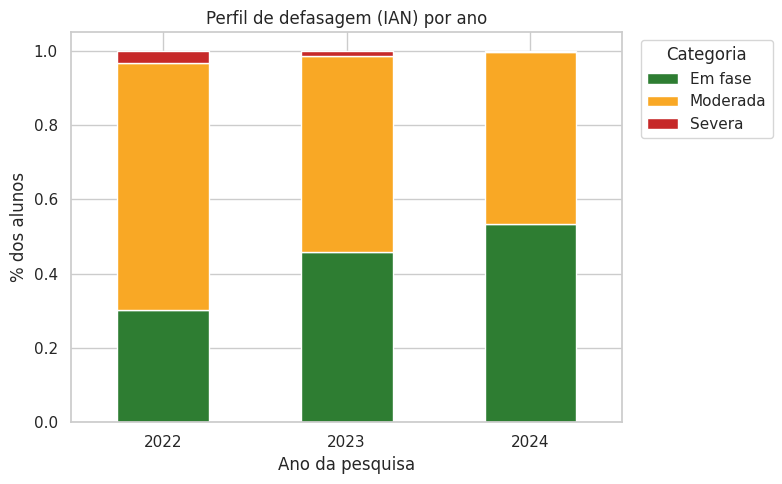

In [ ]:
def categoria_defasagem(d):
    if d >= 0:
        return 'Em fase'
    elif d >= -2:
        return 'Moderada'
    else:
        return 'Severa'

painel_ativo['categoria_defasagem'] = painel_ativo['defasagem'].apply(categoria_defasagem)

tab = pd.crosstab(painel_ativo['ano_pesquisa'], painel_ativo['categoria_defasagem'], normalize='index')
tab = tab[['Em fase','Moderada','Severa']]
print((tab*100).round(1))

ax = tab.plot(kind='bar', stacked=True, figsize=(8,5), color=['#2e7d32','#f9a825','#c62828'])
ax.set_ylabel('% dos alunos')
ax.set_xlabel('Ano da pesquisa')
ax.set_title('Perfil de defasagem (IAN) por ano')
ax.legend(title='Categoria', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Leitura:** a proporção de alunos "Em fase" sobe de forma consistente
(≈30% em 2022 → ≈46% em 2023 → ≈53% em 2024), e a defasagem **severa** praticamente
desaparece (de ≈3,3% para ≈0,3%). É a primeira evidência concreta, ainda na
pergunta 1, de que o programa parece estar reduzindo a defasagem ao longo do
tempo — vamos aprofundar isso na pergunta 10.


##Pergunta 2 — Desempenho acadêmico (IDA): melhorando, estagnado ou caindo?

> *O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao
> longo das fases e anos?*


IDA médio por ano: {2022: 6.09, 2023: 6.66, 2024: 6.34}


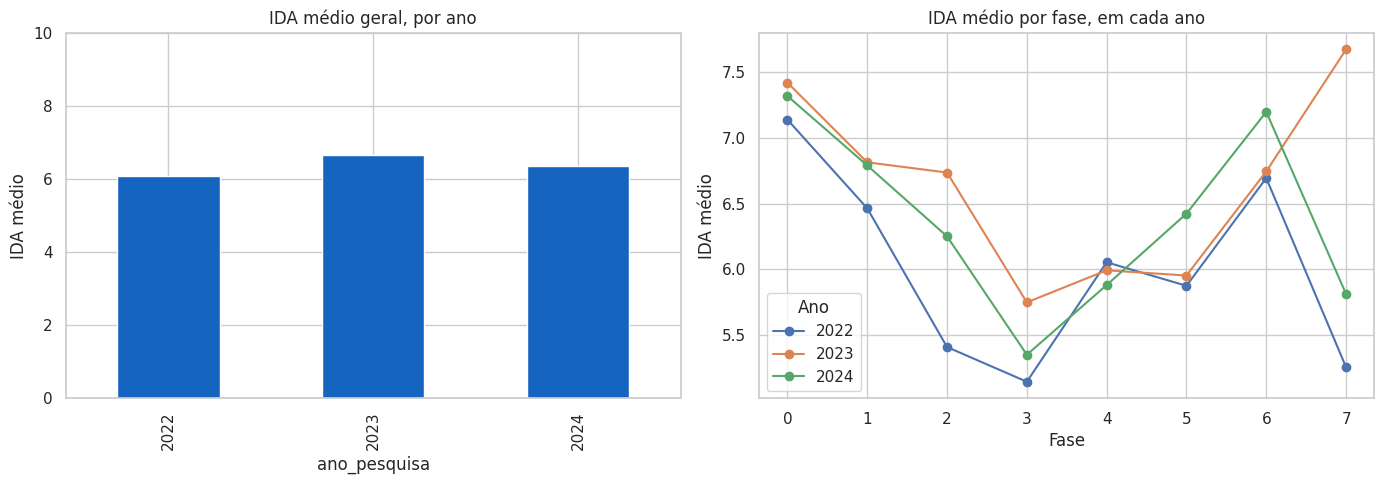

In [ ]:
media_ida_ano = painel_ativo.groupby('ano_pesquisa')['ida'].mean()
print('IDA medio por ano:', media_ida_ano.round(2).to_dict())

pivot_fase_ano = painel_ativo.groupby(['fase','ano_pesquisa'])['ida'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
media_ida_ano.plot(kind='bar', ax=axes[0], color='#1565c0')
axes[0].set_title('IDA medio geral, por ano')
axes[0].set_ylabel('IDA medio')
axes[0].set_ylim(0, 10)

pivot_fase_ano.loc[0:7].plot(marker='o', ax=axes[1])
axes[1].set_title('IDA medio por fase, em cada ano')
axes[1].set_xlabel('Fase')
axes[1].set_ylabel('IDA medio')
axes[1].legend(title='Ano')
plt.tight_layout()
plt.show()


**Leitura:** no agregado, o IDA médio sobe de 2022 para 2023 e recua
um pouco em 2024 — não é uma linha reta de melhora, mas também está longe de
uma queda. Olhando por fase, o padrão mais claro é que **fases mais avançadas
(6º-8º ano, fase 2-3) tendem a ter IDA mais baixo** que as fases iniciais —
possivelmente porque o conteúdo fica mais difícil e o hiato de aprendizagem
acumulado ao longo dos anos escolares pesa mais nessa faixa. As fases mais
altas (6, 7) têm poucos alunos, então as oscilações ano a ano ali devem ser
lidas com cautela (baixo N).


##Pergunta 3 — Engajamento (IEG): relação com desempenho (IDA) e ponto de virada (IPV)

> *O grau de engajamento dos alunos (IEG) tem relação direta com seus
> indicadores de desempenho (IDA) e do ponto de virada (IPV)?*


       ieg    ida    ipv
ieg  1.000  0.543  0.558
ida  0.543  1.000  0.557
ipv  0.558  0.557  1.000


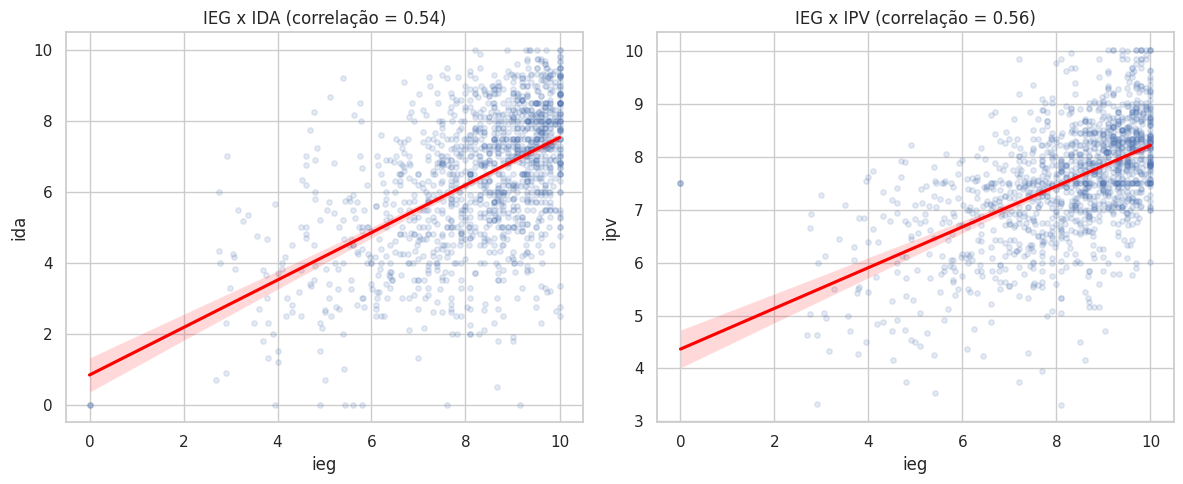

In [ ]:
corr_ieg = painel_ativo[['ieg','ida','ipv']].corr()
print(corr_ieg.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.regplot(data=painel_ativo.sample(min(1500,len(painel_ativo)), random_state=1), x='ieg', y='ida',
            scatter_kws={'alpha':0.15, 's':15}, line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title(f'IEG x IDA (correlacao = {corr_ieg.loc["ieg","ida"]:.2f})')

sns.regplot(data=painel_ativo.sample(min(1500,len(painel_ativo)), random_state=1), x='ieg', y='ipv',
            scatter_kws={'alpha':0.15, 's':15}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title(f'IEG x IPV (correlacao = {corr_ieg.loc["ieg","ipv"]:.2f})')
plt.tight_layout()
plt.show()


**Leitura:** sim, há relação — a correlação de IEG com IDA e com IPV
fica em torno de **0,54-0,56**, moderada-forte para dados sociais. Ou seja,
alunos mais engajados tendem a ter desempenho acadêmico melhor e IPV mais
alto, mas a relação está longe de ser perfeita (correlação bem abaixo de 1) —
o que é esperado: engajamento é só um dos fatores, não o único.


##Pergunta 4 — Autoavaliação (IAA): coerente com desempenho e engajamento reais?

> *As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu
> desempenho real (IDA) e engajamento (IEG)?*


       iaa    ida    ieg
iaa  1.000  0.114  0.133
ida  0.114  1.000  0.543
ieg  0.133  0.543  1.000


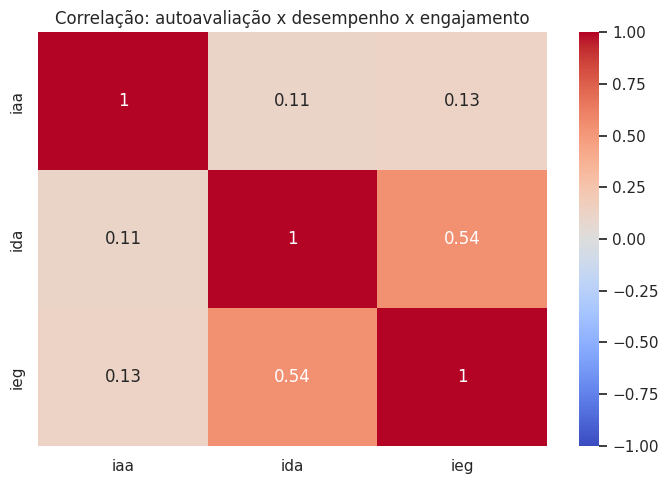

In [ ]:
corr_iaa = painel_ativo[['iaa','ida','ieg']].corr()
print(corr_iaa.round(3))

fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(painel_ativo[['iaa','ida','ieg']].corr(), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlacao: autoavaliacao x desempenho x engajamento')
plt.tight_layout()
plt.show()


**Leitura — e aqui tem uma surpresa:** a correlação do IAA com IDA e
com IEG é **fraca** (em torno de 0,11 e 0,13). Ou seja, **como o aluno se
percebe não está fortemente alinhado com seu desempenho real ou seu
engajamento observado**. Isso pode significar várias coisas — vieses de
autoavaliação (excesso de otimismo ou de autocrítica em crianças/adolescentes),
o questionário de autoavaliação capturando bem-estar emocional geral (não
desempenho), ou simplesmente que a percepção subjetiva e o desempenho objetivo
são, de fato, dimensões distintas da experiência do aluno. Vale a pena a
Passos Mágicos investigar esse descolamento com a equipe pedagógica.


##Pergunta 5 — Aspectos psicossociais (IPS): antecedem quedas de desempenho?

> *Há padrões psicossociais (IPS) que antecedem quedas de desempenho
> acadêmico ou de engajamento?*

Essa pergunta pede uma relação **temporal** ("antecedem"), então uma
correlação no mesmo ano não é suficiente — precisamos comparar o IPS de um
aluno em um ano com o que aconteceu com ele **no ano seguinte**. Como
descobrimos que o `RA` é persistente entre anos (seção 3), dá para montar
pares (ano N, ano N+1) para o mesmo aluno.


1353 pares de anos consecutivos para o mesmo aluno.

IPS_N médio — quem piorou a defasagem no ano seguinte vs quem não piorou:
                   mean  count
piorou_defasagem              
False             5.917   1057
True              6.190    234

IPS_N médio — quem teve queda de IDA no ano seguinte vs quem não teve:
           mean  count
caiu_ida              
0.0       6.032    575
1.0       5.870    670

Correlação IPS_N x defasagem_N1: -0.184


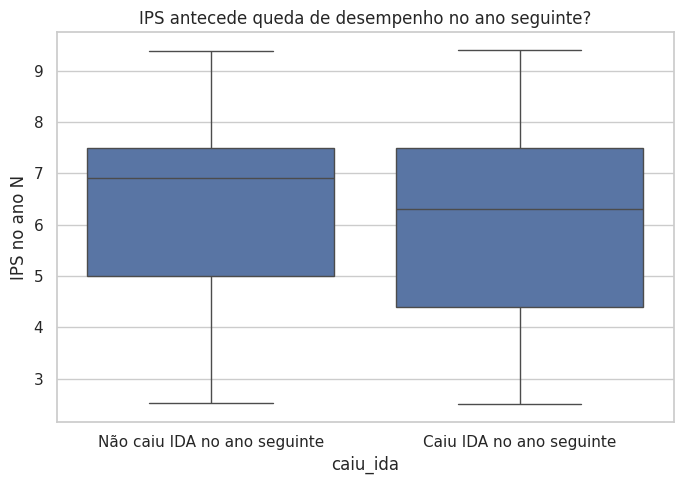

In [ ]:
pares = []
for ra, sub in painel_ativo.groupby('RA'):
    anos = sorted(sub['ano_pesquisa'].unique())
    for i in range(len(anos)-1):
        n, n1 = anos[i], anos[i+1]
        if n1 - n == 1:
            r0 = sub[sub['ano_pesquisa']==n].iloc[0]
            r1 = sub[sub['ano_pesquisa']==n1].iloc[0]
            pares.append({
                'RA': ra, 'ano_N': n,
                'ips_N': r0['ips'], 'ida_N': r0['ida'], 'ida_N1': r1['ida'],
                'defasagem_N': r0['defasagem'], 'defasagem_N1': r1['defasagem'],
            })
pares_df = pd.DataFrame(pares)
pares_df['piorou_defasagem'] = pares_df['defasagem_N1'] < pares_df['defasagem_N']
pares_df['caiu_ida'] = np.where(pares_df['ida_N'].notna() & pares_df['ida_N1'].notna(),
                                  pares_df['ida_N1'] < pares_df['ida_N'], np.nan)

print(f'{len(pares_df)} pares de anos consecutivos para o mesmo aluno.')

print('IPS_N medio — quem piorou a defasagem no ano seguinte vs quem nao piorou:')
print(pares_df.groupby('piorou_defasagem')['ips_N'].agg(['mean','count']).round(3))

print('IPS_N medio — quem teve queda de IDA no ano seguinte vs quem nao teve:')
print(pares_df.dropna(subset=['caiu_ida']).groupby('caiu_ida')['ips_N'].agg(['mean','count']).round(3))

print('Correlação IPS_N x defasagem_N1:', pares_df[['ips_N','defasagem_N1']].corr().iloc[0,1].round(3))

fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=pares_df.dropna(subset=['caiu_ida']), x='caiu_ida', y='ips_N', ax=ax)
ax.set_xticklabels(['Nao caiu IDA no ano seguinte','Caiu IDA no ano seguinte'])
ax.set_ylabel('IPS no ano N')
ax.set_title('IPS antecede queda de desempenho no ano seguinte?')
plt.tight_layout()
plt.show()


**Leitura honesta:** ao contrário do que eu esperava antes de rodar essa
análise, **o IPS isoladamente não é um bom preditor linear de queda futura**
— a diferença entre os grupos é pequena, e no caso da defasagem a direção
chega a ser levemente contraintuitiva (quem piora a defasagem tem IPS médio
um pouco **maior**, não menor). Uma hipótese razoável: a equipe de psicologia
pode estar direcionando mais atenção/acompanhamento justamente a quem já está
com dificuldade, o que tende a "misturar" o sinal isolado de IPS. Isso não
significa que o IPS seja inútil — no Notebook 2 ele entra como uma de várias
features combinadas no modelo, e combinações de indicadores costumam
carregar mais sinal do que cada um sozinho (voltaremos a isso na pergunta 8).


##Pergunta 6 — Aspectos psicopedagógicos (IPP): confirmam ou contradizem o IAN?

> *As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem
> identificada pelo IAN?*


                      mean  count
categoria_defasagem              
Em fase              7.677    907
Moderada             7.465   1058
Severa               7.010     17

Correlação IPP x defasagem (contínua): 0.177


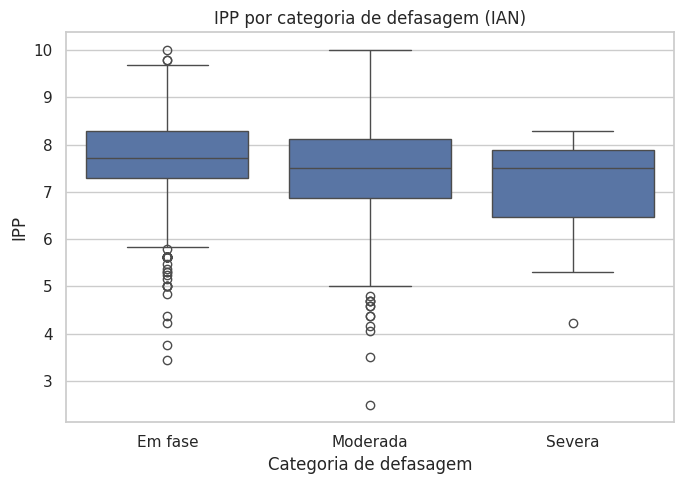

In [ ]:
tab_ipp = painel_ativo.groupby('categoria_defasagem')['ipp'].agg(['mean','count']).reindex(['Em fase','Moderada','Severa'])
print(tab_ipp.round(3))

print('Correlaçao IPP x defasagem (continua):', painel_ativo[['ipp','defasagem']].corr().iloc[0,1].round(3))

fig, ax = plt.subplots(figsize=(7,5))
ordem = ['Em fase','Moderada','Severa']
sns.boxplot(data=painel_ativo, x='categoria_defasagem', y='ipp', order=ordem, ax=ax)
ax.set_title('IPP por categoria de defasagem (IAN)')
ax.set_xlabel('Categoria de defasagem')
ax.set_ylabel('IPP')
plt.tight_layout()
plt.show()


**Leitura:** o IPP **confirma** o IAN — a média de IPP cai de forma
consistente conforme a defasagem piora (Em fase > Moderada > Severa), e a
correlação (embora moderada, ~0,18) tem o sinal esperado. É importante notar
que o grupo "Severa" tem poucos alunos (efeito da própria melhora do programa
mostrada na pergunta 1), então a média desse grupo é menos estável — mas a
direção do padrão é clara e consistente com o que o IAN capta.


##Pergunta 7 — Ponto de virada (IPV): o que mais o influencia ao longo do tempo?

> *Quais comportamentos — acadêmicos, emocionais ou de engajamento — mais
> influenciam o IPV ao longo do tempo?*


ipv    1.000
ipp    0.606
ieg    0.558
ida    0.557
iaa    0.062
ips   -0.050
Name: ipv, dtype: float64


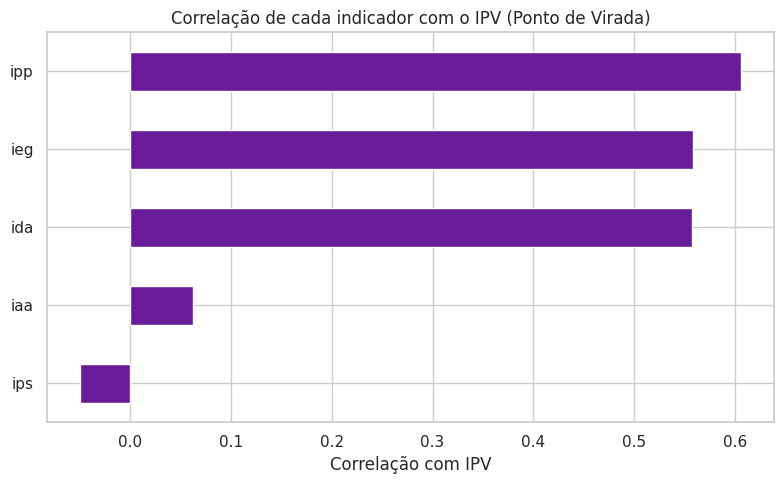

In [ ]:
corr_ipv = painel_ativo[['ipv','ipp','ieg','ida','iaa','ips']].corr()['ipv'].sort_values(ascending=False)
print(corr_ipv.round(3))

fig, ax = plt.subplots(figsize=(8,5))
corr_ipv.drop('ipv').sort_values().plot(kind='barh', ax=ax, color='#6a1b9a')
ax.set_title('Correlacao de cada indicador com o IPV (Ponto de Virada)')
ax.set_xlabel('Correlacao com IPV')
plt.tight_layout()
plt.show()


**Leitura:** os indicadores mais associados ao IPV são o **IPP**
(psicopedagógico, ~0,61), o **IEG** (engajamento, ~0,56) e o **IDA**
(desempenho acadêmico, ~0,56) — ou seja, o "ponto de virada" está muito mais
ligado a como professores/psicopedagogos avaliam o desenvolvimento do aluno e
ao seu engajamento/desempenho concreto do que à autoavaliação (IAA, ~0,06) ou
ao aspecto psicossocial isolado (IPS, praticamente 0). Isso sugere que o IPV
capta uma mudança que fica visível "de fora" (comportamento, entrega,
aprendizado) mais do que uma mudança que o aluno relata sentir internamente.


##Pergunta 8 — Multidimensionalidade: quais combinações elevam mais o INDE?

> *Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a
> nota global do aluno (INDE)?*


Correlação de cada indicador com o INDE:
inde    1.000
ida     0.785
ieg     0.746
ipv     0.720
ipp     0.539
iaa     0.397
ips     0.199
Name: inde, dtype: float64

N total analisado: 1975

Top 5 combinações (maior INDE médio):
                                      mean  count
ida_alto ieg_alto ips_alto ipp_alto              
alto     alto     alto     alto      8.424    307
                  baixo    alto      8.092    262
                  alto     baixo     7.925     50
         baixo    alto     alto      7.874    129
baixo    alto     alto     alto      7.778     99

Bottom 3 combinações (menor INDE médio):
                                      mean  count
ida_alto ieg_alto ips_alto ipp_alto              
baixo    baixo    baixo    alto      6.642    155
                  alto     baixo     6.415    172
                  baixo    baixo     6.047    185


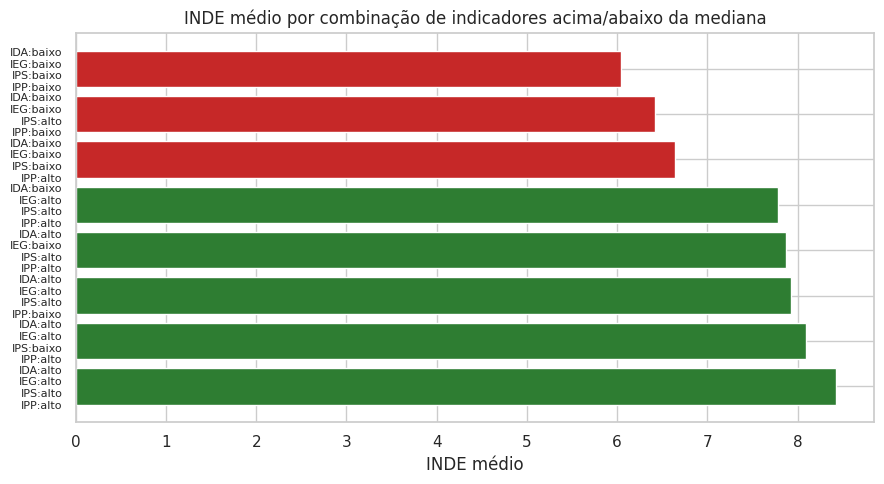

In [ ]:
cols_q8 = ['inde','ida','ieg','ips','ipp','iaa','ipv']
print('Correlacao de cada indicador com o INDE:')
print(painel_ativo[cols_q8].corr()['inde'].sort_values(ascending=False).round(3))


sub = painel_ativo.dropna(subset=['ida','ieg','ips','ipp','inde']).copy()
for c in ['ida','ieg','ips','ipp']:
    sub[c+'_alto'] = np.where(sub[c] >= sub[c].median(), 'alto', 'baixo')

combo = sub.groupby(['ida_alto','ieg_alto','ips_alto','ipp_alto'])['inde'].agg(['mean','count'])
combo = combo.sort_values('mean', ascending=False)
print(f'N total analisado: {len(sub)}')

print('Top 5 combinacoes (maior INDE medio):')
print(combo.head(5).round(3))

print('Bottom 3 combinacoes (menor INDE medio):')
print(combo.tail(3).round(3))

fig, ax = plt.subplots(figsize=(9,5))
top_bottom = pd.concat([combo.head(5), combo.tail(3)])
labels = ['\n'.join([f'{n}:{v}' for n,v in zip(['IDA','IEG','IPS','IPP'], idx)]) for idx in top_bottom.index]
ax.barh(range(len(top_bottom)), top_bottom['mean'], color=['#2e7d32']*5 + ['#c62828']*3)
ax.set_yticks(range(len(top_bottom)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('INDE medio')
ax.set_title('INDE medio por combinação de indicadores acima/abaixo da mediana')
plt.tight_layout()
plt.show()


**Leitura:** isoladamente, quem mais "puxa" o INDE para cima é o
**IDA** (desempenho acadêmico, correlação ~0,79), seguido de **IEG**
(engajamento, ~0,75) e **IPV** (~0,72) — o que faz todo sentido, já que esses
três têm os maiores pesos na fórmula oficial do INDE (0,2 cada). O **IPS**
é o que menos se relaciona linearmente com o INDE (~0,20). Mas o achado mais
interessante é o efeito **combinado**: alunos com os 4 indicadores (IDA, IEG,
IPS, IPP) acima da mediana **ao mesmo tempo** chegam a um INDE médio bem mais
alto do que a soma das partes sugeriria, enquanto ter todos abaixo da mediana
puxa o INDE para os patamares mais baixos da base — reforçando que o impacto
sobre o INDE não é apenas aditivo, é também sobre **consistência** entre as
dimensões acadêmica, comportamental e psicopedagógica.


##Pergunta 9 — Previsão de risco com Machine Learning

> *Quais padrões nos indicadores permitem identificar alunos em risco antes
> de queda no desempenho ou aumento da defasagem? Construa um modelo
> preditivo que mostre uma probabilidade do aluno entrar em risco de
> defasagem.*

Essa pergunta é respondida em detalhe no **`2_modelo_preditivo_risco_defasagem.ipynb`**
— o notebook separado dedicado ao modelo de Machine Learning (feature
engineering, treino/teste, comparação de modelos, avaliação, e exportação do
modelo para o Streamlit). Fizemos questão de manter a modelagem em um
notebook próprio, como pede o enunciado do desafio.

Um resumo rápido do que está lá: o alvo é binário — **`risco_defasagem = 1`**
se o aluno está abaixo da fase ideal (`defasagem < 0`) — e as features usadas
são os indicadores que **não** entram na fórmula do IAN (IDA, IEG, IAA, IPS,
IPP, IPV), mais dados demográficos e de histórico (idade, tempo de casa, rede
de ensino, INDE e Pedra do ano anterior). O melhor modelo (Gradient
Boosting) chega a **ROC-AUC ≈ 0,87**, superando redes neurais e regressão
logística testadas em paralelo.


##Pergunta 10 — Efetividade do programa: melhora consistente entre as Pedras?

> *Os indicadores mostram melhora consistente ao longo do ciclo nas
> diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o
> impacto real do programa?*

Usando de novo os pares (ano N, ano N+1) do mesmo aluno, dá pra ver: (a) para
onde os alunos de cada Pedra "migram" no ano seguinte, e (b) como o INDE
médio de cada grupo evolui.


1241 pares com Pedra válida nos dois anos.

Matriz de transição (linha = pedra no ano N, coluna = pedra no ano N+1):
pedra_N1  Quartzo  Agata  Ametista  Topazio
pedra_N                                    
Quartzo      40.9   47.7      11.4      0.0
Agata        18.6   47.2      28.3      5.9
Ametista      5.4   21.2      47.7     25.7
Topazio       0.7    4.8      31.7     62.8

Subiu de pedra: 24.1% | Manteve: 50.7% | Caiu: 25.2%

INDE médio no ano N vs ano N+1, por pedra inicial:
          inde_N  inde_N1
pedra_N                  
Quartzo    5.485    6.078
Agata      6.611    6.688
Ametista   7.533    7.457
Topazio    8.408    8.121


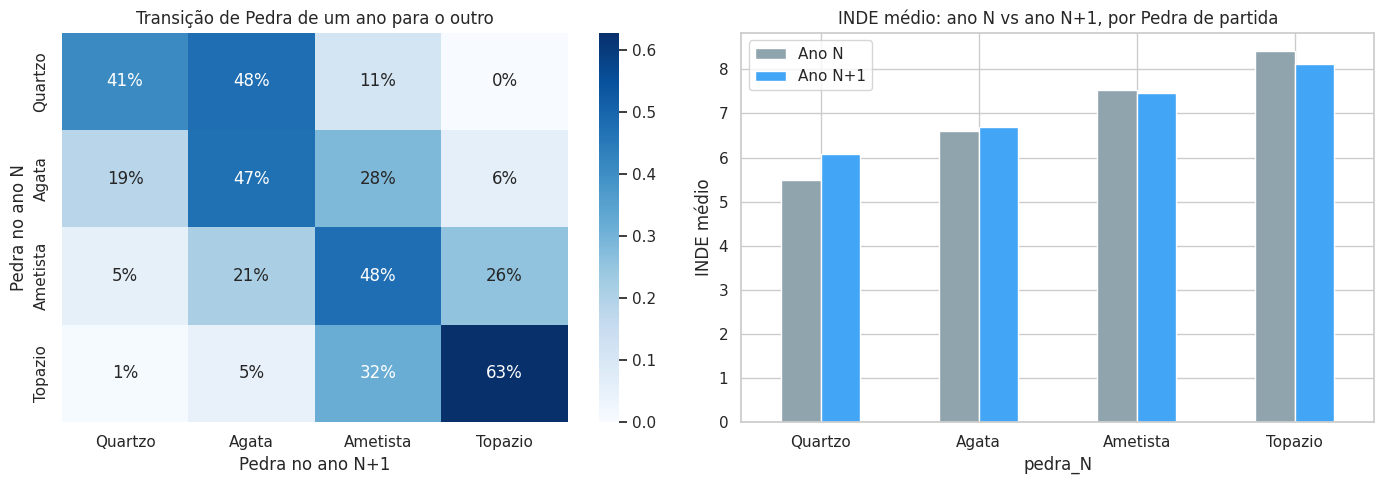

In [ ]:
ORDEM_PEDRA = ['Quartzo','Agata','Ametista','Topazio']

pares_pedra = []
for ra, sub in painel_ativo.groupby('RA'):
    anos = sorted(sub['ano_pesquisa'].unique())
    for i in range(len(anos)-1):
        n, n1 = anos[i], anos[i+1]
        if n1 - n == 1:
            r0 = sub[sub['ano_pesquisa']==n].iloc[0]
            r1 = sub[sub['ano_pesquisa']==n1].iloc[0]
            pares_pedra.append({'RA': ra, 'pedra_N': r0['pedra_atual'], 'pedra_N1': r1['pedra_atual'],
                                 'inde_N': r0['inde'], 'inde_N1': r1['inde']})
pp = pd.DataFrame(pares_pedra).dropna(subset=['pedra_N','pedra_N1'])
print(f'{len(pp)} pares com Pedra valida nos dois anos.')

trans = pd.crosstab(pp['pedra_N'], pp['pedra_N1'], normalize='index').reindex(index=ORDEM_PEDRA, columns=ORDEM_PEDRA)

print('Matriz de transição (linha = pedra no ano N, coluna = pedra no ano N+1):')
print((trans*100).round(1))

idx = {p:i for i,p in enumerate(ORDEM_PEDRA)}
pp['delta'] = pp['pedra_N1'].map(idx) - pp['pedra_N'].map(idx)

print(f"Subiu de pedra: {(pp['delta']>0).mean():.1%} | Manteve: {(pp['delta']==0).mean():.1%} | Caiu: {(pp['delta']<0).mean():.1%}")

inde_eval = pp.groupby('pedra_N')[['inde_N','inde_N1']].mean().reindex(ORDEM_PEDRA)

print('INDE medio no ano N vs ano N+1, por pedra inicial:')
print(inde_eval.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.heatmap(trans, annot=True, fmt='.0%', cmap='Blues', ax=axes[0])
axes[0].set_title('Transicao de Pedra de um ano para o outro')
axes[0].set_ylabel('Pedra no ano N'); axes[0].set_xlabel('Pedra no ano N+1')

inde_eval.plot(kind='bar', ax=axes[1], color=['#90a4ae','#42a5f5'])
axes[1].set_title('INDE medio: ano N vs ano N+1, por Pedra de partida')
axes[1].set_ylabel('INDE medio')
axes[1].legend(['Ano N','Ano N+1'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Leitura — resultado nuançado, não uma linha reta de melhora:**

- No nível agregado (pergunta 1), a defasagem severa cai e a proporção "Em
  fase" sobe ano a ano — isso é evidência real de impacto positivo do
  programa como um todo.
- Mas ao acompanhar os **mesmos alunos** de um ano para o outro, o quadro é
  mais misto: cerca de 24% sobem de Pedra, 51% mantêm, e 25% caem — não é uma
  progressão unânime.
- O achado mais interessante: o INDE médio **sobe visivelmente** para quem
  começa em Quartzo (a pedra mais baixa), fica praticamente estável para
  Ágata, e **recua** para quem começa em Ametista ou Topázio (as pedras mais
  altas).

Esse padrão é compatível tanto com **regressão à média** (um fenômeno
estatístico esperado: quem está nos extremos tende a se aproximar da média no
período seguinte) quanto com uma leitura mais otimista: **o programa parece
ter o maior impacto justamente onde mais precisa** — nos alunos que mais
precisam de suporte (Quartzo). Não dá para separar as duas explicações só com
esses dados (seria preciso um grupo de controle), mas ambas são consistentes
com o programa estar funcionando, e vale a pena a Passos Mágicos monitorar de
perto a leve queda dos alunos em Topázio/Ametista — não necessariamente um
problema, mas um ponto de atenção.


##Pergunta 11 — Insights e criatividade

> *Você pode adicionar mais insights e pontos de vista não abordados nas
> perguntas, utilize a criatividade e a análise dos dados para trazer
> sugestões para a Passos Mágicos.*

Três achados que apareceram "de bônus" durante a exploração e merecem
destaque.


###11.1 — A rede de ensino é o fator com a maior diferença de risco que encontramos

Maior até do que qualquer indicador comportamental isolado.


                 mean  count  risco_pct
rede_ensino                            
Pública      0.628941   2474       62.9
Privada      0.226236    526       22.6


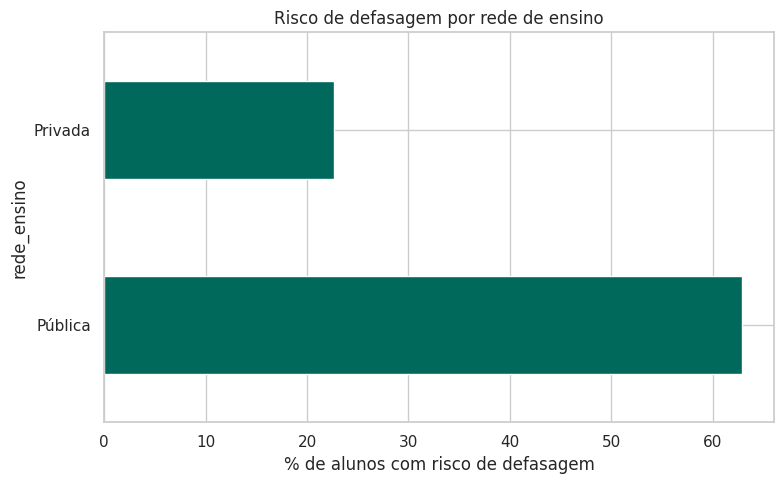

In [ ]:
risco_rede = painel_ativo.assign(risco=(painel_ativo['defasagem']<0).astype(int)).groupby('rede_ensino')['risco'].agg(['mean','count'])
risco_rede = risco_rede[risco_rede['count'] >= 20].sort_values('mean', ascending=False)
risco_rede['risco_pct'] = (risco_rede['mean']*100).round(1)
print(risco_rede)

fig, ax = plt.subplots(figsize=(8,5))
risco_rede['mean'].mul(100).plot(kind='barh', ax=ax, color='#00695c')
ax.set_xlabel('% de alunos com risco de defasagem')
ax.set_title('Risco de defasagem por rede de ensino')
plt.tight_layout()
plt.show()


**Leitura:** alunos em escola **privada** (via apadrinhamento/bolsa)
têm uma taxa de risco de defasagem muito menor (≈23%) do que alunos em escola
**pública** (≈63%) — uma diferença de ~40 pontos percentuais. Isso é maior do
que qualquer relação que vimos entre os indicadores comportamentais isolados
(IEG, IAA, IPS) e o desempenho. **Importante ressalva:** isso é correlação,
não necessariamente causalidade — pode refletir tanto a qualidade/estrutura
da escola quanto um efeito de seleção (alunos com perfil mais forte podem ser
priorizados para vagas de apadrinhamento). De todo modo, é um sinal forte o
suficiente para a Passos Mágicos aprofundar: será que vale intensificar o
suporte pedagógico especificamente para a rede pública?


###11.2 — Gap de gênero, menor mas presente


In [ ]:
risco_genero = painel_ativo.assign(risco=(painel_ativo['defasagem']<0).astype(int)).groupby('genero')['risco'].mean()
print((risco_genero*100).round(1))


genero
Feminino     52.9
Masculino    59.3
Name: risco, dtype: float64


Meninos têm uma taxa de risco de defasagem um pouco maior que meninas
(≈59% vs ≈53%) — um gap mais modesto que o de rede de ensino, mas consistente
com um padrão amplamente documentado na literatura educacional (meninos
tendem a apresentar taxas mais altas de repetência/defasagem em vários
contextos).


###11.3 — A evasão da base é consistente com os relatórios oficiais da Passos Mágicos

Já vimos na seção 3 que ~25-30% dos alunos de um ano não aparecem no ano
seguinte. Vale destacar: essa ordem de grandeza **bate com os relatórios de
atividades anuais** que a própria associação publica (que também reportam
evasão na casa de ~29% em anos recentes) — um bom sinal de consistência entre
esta base de dados e a realidade operacional relatada pela Passos Mágicos.
Fica como sugestão de próximo passo natural: um modelo de **previsão de
evasão** (complementar ao de risco de defasagem construído no Notebook 2)
poderia ajudar a equipe a intervir antes mesmo do aluno sair do programa.


---
#9. Exportando a base tratada para o Notebook 2


In [ ]:
import os

#Garante que o diretório de saída existe
os.makedirs(f'{CAMINHO_PROJETO}/data', exist_ok=True)

caminho_saida = f'{CAMINHO_PROJETO}/data/painel_tratado.csv'
painel_ativo.to_csv(caminho_saida, index=False)

print(f'Base tratada salva em: {caminho_saida}')
print(f'Shape final: {painel_ativo.shape}')

Base tratada salva em: /content/data/painel_tratado.csv
Shape final: (3003, 27)


---
#10. Conclusões

- A base do PEDE Passos Mágicos tem uma estrutura consistente ano a ano, mas
  exige um trabalho real de limpeza antes de qualquer análise (colunas com
  nomes diferentes, categorias com grafias diferentes, um bug de coluna
  trocada em 2024, um bug de formatação de data em 2023, valores-placeholder
  como `"INCLUIR"`).
- A fórmula do INDE bate quase exatamente com os dados — o que é ótimo para
  confiabilidade, mas também um alerta importante de vazamento de dados para
  a etapa de modelagem (por isso o alvo do modelo é o **risco de defasagem**,
  não o INDE/Pedra).
- Os indicadores comportamentais (IEG, IPP, IDA) têm relação moderada a forte
  entre si e com o INDE/IPV; já a autoavaliação (IAA) e o indicador
  psicossocial (IPS) mostram relações mais fracas com o desempenho objetivo —
  um achado que vale investigação qualitativa por parte da equipe pedagógica.
- Há evidência real de melhora ao longo dos anos no agregado (menos defasagem
  severa, mais alunos "em fase"), com efeito mais forte nos alunos que
  começam em situação mais vulnerável (Pedra Quartzo).
- A rede de ensino (pública vs. privada) é o fator com a maior diferença de
  risco de defasagem observada — maior sinal isolado do que qualquer
  indicador comportamental.
- O modelo preditivo de risco de defasagem (Notebook 2) usa exatamente esses
  aprendizados: exclui os componentes que vazariam o alvo, usa histórico do
  aluno como feature de tendência, e testa múltiplos algoritmos antes de
  escolher o mais adequado.
